In [1]:
from myutils import *
from src import *

In [2]:
file_tree = [
    r'__estimates__\spade_5px\*',
]

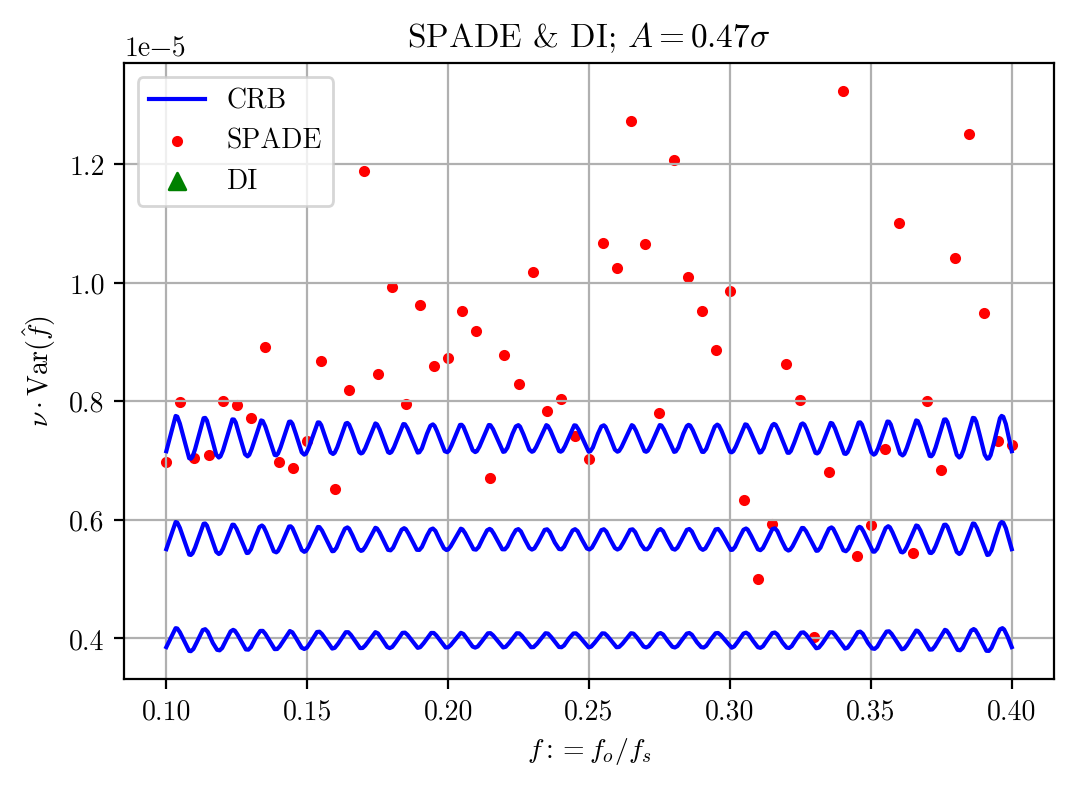

In [3]:
x_axis = np.linspace(0.1, 0.4, 1000)
A = 5 * DMD.PIXEL_SIZE / 2

crb = (1 / FisherInformation([A], x_axis))[0]

plot(x_axis, crb, 'b', label='CRB')
plot(x_axis, 0.7 * crb, 'b')
plot(x_axis, 1.3 * crb, 'b')

for i, file in enumerate(file_tree):
    for f in glob(file):
        c = LoadEstimates(f) 
        scatter(c.metadata.ground_truth, c.frequency_estimates.var(ddof=1) * c.photons.mean(), 
                marker=['.', '^'][i], c=['r', 'g'][i])


scatter([], [], marker='.', c='r', label='SPADE')
scatter([], [], marker='^', c='g', label='DI')


plt.xlabel(r'$f := f_o / f_s$')
plt.ylabel(r'$\nu\cdot{\rm Var}(\hat f)$')
plt.title(rf'SPADE & DI; $A = {np.round(5 * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$')
plt.show()

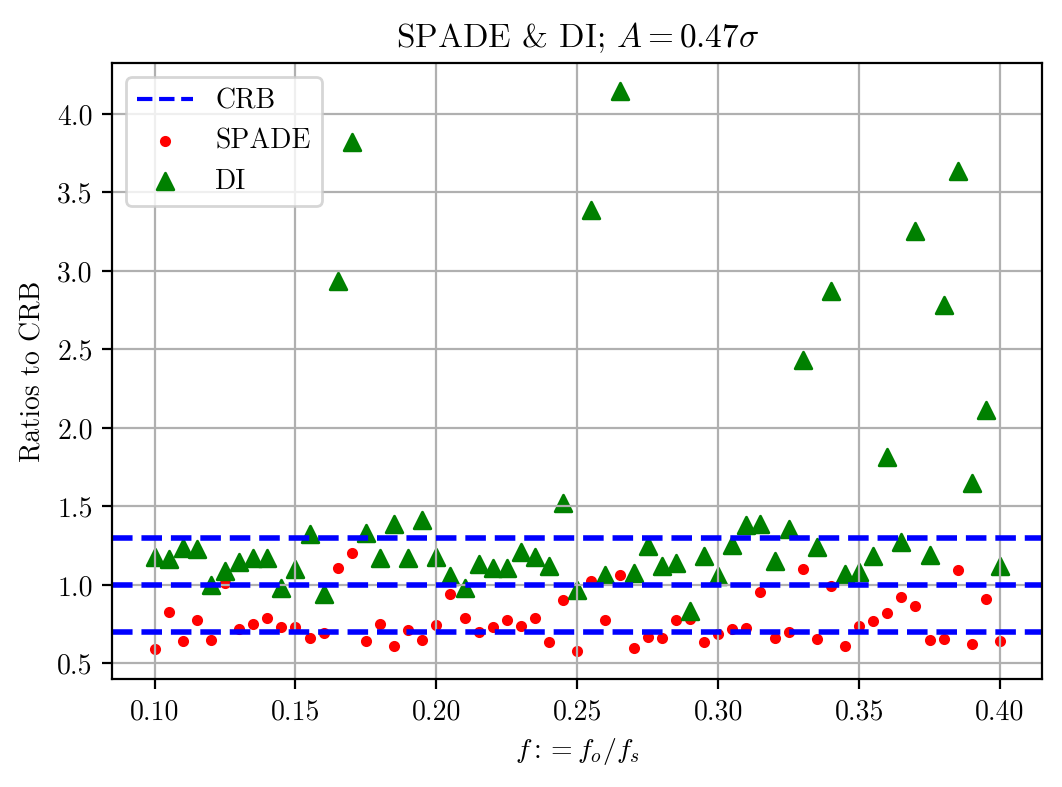

In [70]:
for i, file in enumerate(file_tree):
    for f in glob(file):
        c = LoadEstimates(f)
        x = c.metadata.ground_truth
        y = c.frequency_estmates.var(ddof=1) * c.photons.mean() / FIM_CRB().crb(c.metadata.amplitude, x)
        scatter(x, y, marker=['.', '^'][i], c=['r', 'g'][i])


axline(0.7, c='b', w=2)
axline(1, c='b', w=2)
axline(1.3, c='b', w=2)

plot([], [], 'b--', label='CRB')

scatter([], [], marker='.', c='r', label='SPADE')
scatter([], [], marker='^', c='g', label='DI')

plt.xlabel(r'$f := f_o / f_s$')
plt.ylabel(r'Ratios to CRB')
plt.title(rf'SPADE & DI; $A = {np.round(5 * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$')
plt.show()

In [60]:

ff = lambda k, s: 1/8*np.exp(-(s/(2*103))**2)*(s/103+2*(-1)**(k+1))**2

In [65]:
ff(0, 0*DMD.PIXEL_SIZE) + ff(1, 0*DMD.PIXEL_SIZE)

1.0

In [ ]:
ff(0, 5*DMD.PIXEL_SIZE) + ff(1, 5*DMD.PIXEL_SIZE)